### 工作進度  
* 【置頂】**筆記內容架構**與**量化技術分析系統**相關資訊請參閱[260531筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/260531%E7%AD%86%E8%A8%98.ipynb)之「工作進度」。  

* 引入模組與定義公用函式  

In [ ]:
import numpy as np
import mysys
import markdown
from IPython.core.display import HTML

In [ ]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if results is not None :
        if buttom_pattern is True and '底部型態' in images :
            print('底型反轉交易策略：')
            display(images['底部型態'])
        print('解盤內容：')
        if '整體評價' in images and images['整體評價'] is not None  :
            display(images['整體評價'])
        result_md   = results.to_markdown(tablefmt="grid")
        result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
        display(HTML(result_html))

* 更新量化技術分析資料庫  

In [ ]:
mysys.UpdateStockDatabase()

* 建立「解盤」物件    

In [ ]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

> **開盤**：加權指數開高往兩個前高邁進。  
> 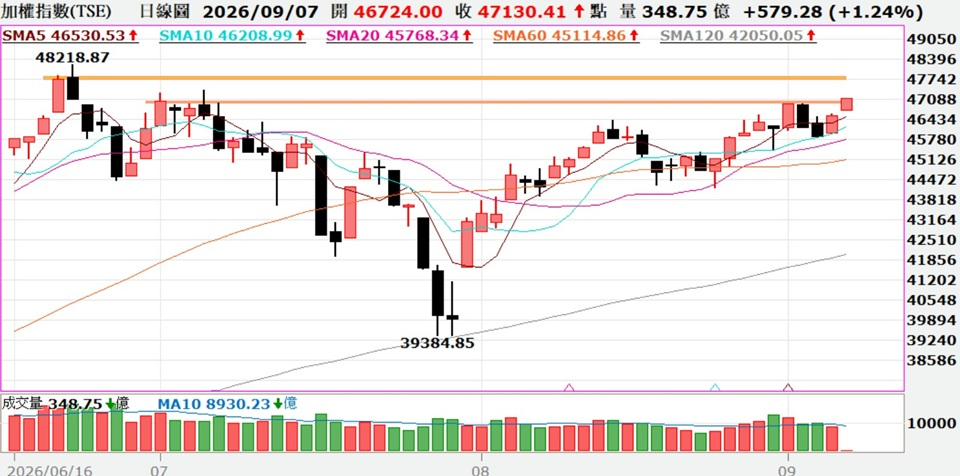  
> **盤中**：指數量能溫和，不過漲幅緩步墊高一些。  
> 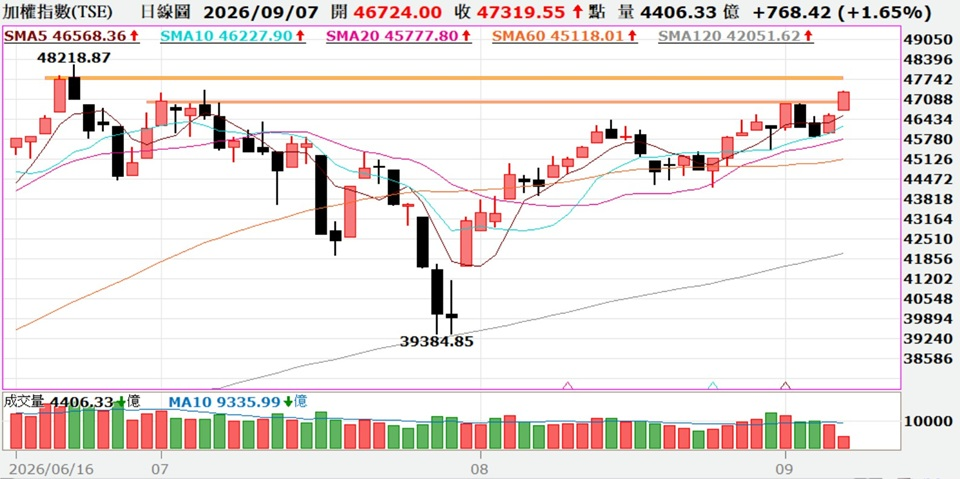  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **開盤**：櫃買指數也是開高，但還在短線盤整區間。  
> 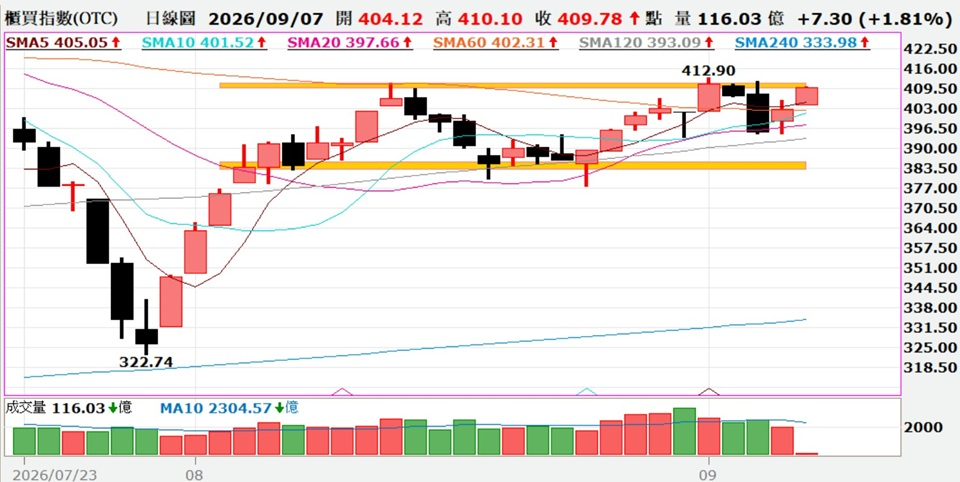  
> **盤中**：指數量能溫和，不過漲幅緩步墊高一些。  
> 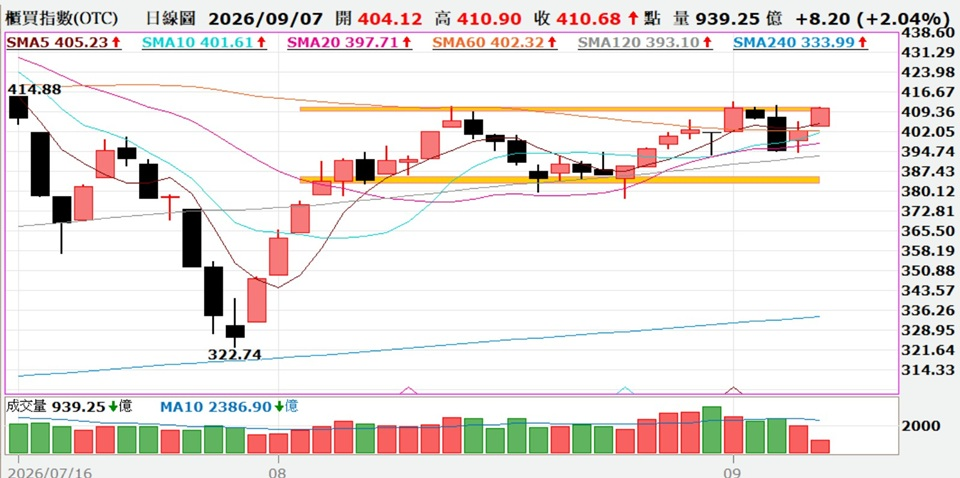  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股篩選  

* 選股程序    

In [ ]:
results = analysis.screener()

In [ ]:
for stock_info in results :
    print('股票代碼 ＝ {} ， 股票名稱 ＝ {} '.format(stock_info[0],stock_info[1]))

* 篩選結果  
  - TODO

* 觀察股列表  
  TODO  

* 技術面+籌碼面分類整理表  
  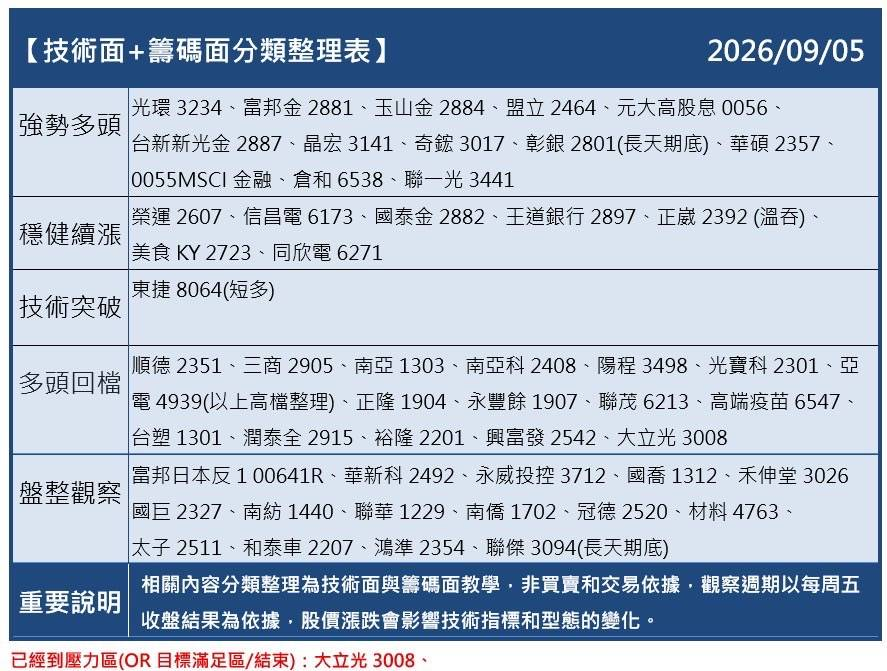  

### 個股解盤  

* 裕隆(2201)  
  看法：TODO。  

> **盤後**：量化技術分析  

In [ ]:
stock_analysis(analysis,'2201')

> **盤後**：底部反轉交易策略分析  

In [ ]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2026-03-02'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2026-07-06']['Close']

    # 設定底部日期與價格
    bottom_date  = '2026-04-10'
    bottom_price = range_prices.loc['2026-04-10']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))
    
    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)]
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

In [ ]:
image = mysys.DrawOnKlineChart('2201','2025-12-09','2026-09-07',line_drawing_callback)
display(image)

籌碼面：  
法人○○( )：外資○○( )、投信○○( )、自營○○( )。  
主力○○( )。  
分公司買賣家數差○○( )。  
融資○○( )、融券○○( )。  